# AOMIC-ID1000 - Automated Ontology and Tiered Results

This notebook shows the automated data understanding that grounds the ontology, the
resulting ontology graph, how well the semantic ontology matches the data-driven
clusters, the complexity-tier ladder, and per-tier engine performance.

For hands-on exploration, open `../ontology/ontology_viewer.html` in a browser: an
interactive tree with expand/collapse, drag, and top-down / left-right / radial layouts.

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
ROOT = Path.cwd().parent
IND = "#6366f1"; GRN = "#10b981"; ORG = "#f59e0b"; RED = "#ef4444"; BLU = "#38bdf8"

import networkx as nx
onto = json.load(open(ROOT / "ontology" / "subclass_structure.json"))
explore = json.load(open(ROOT / "ontology" / "exploration_report.json"))
report = json.load(open(ROOT / "ontology" / "ontology_report.json"))
tiers = json.load(open(ROOT / "results" / "tiers_summary.json"))["tiers"]
print("domains:", len(onto["domains"]), "| ARI ontology vs clusters:",
      report.get("cluster_agreement",{}).get("adjusted_rand_index"))

domains: 5 | ARI ontology vs clusters: 0.478


## 1. The ontology as a graph

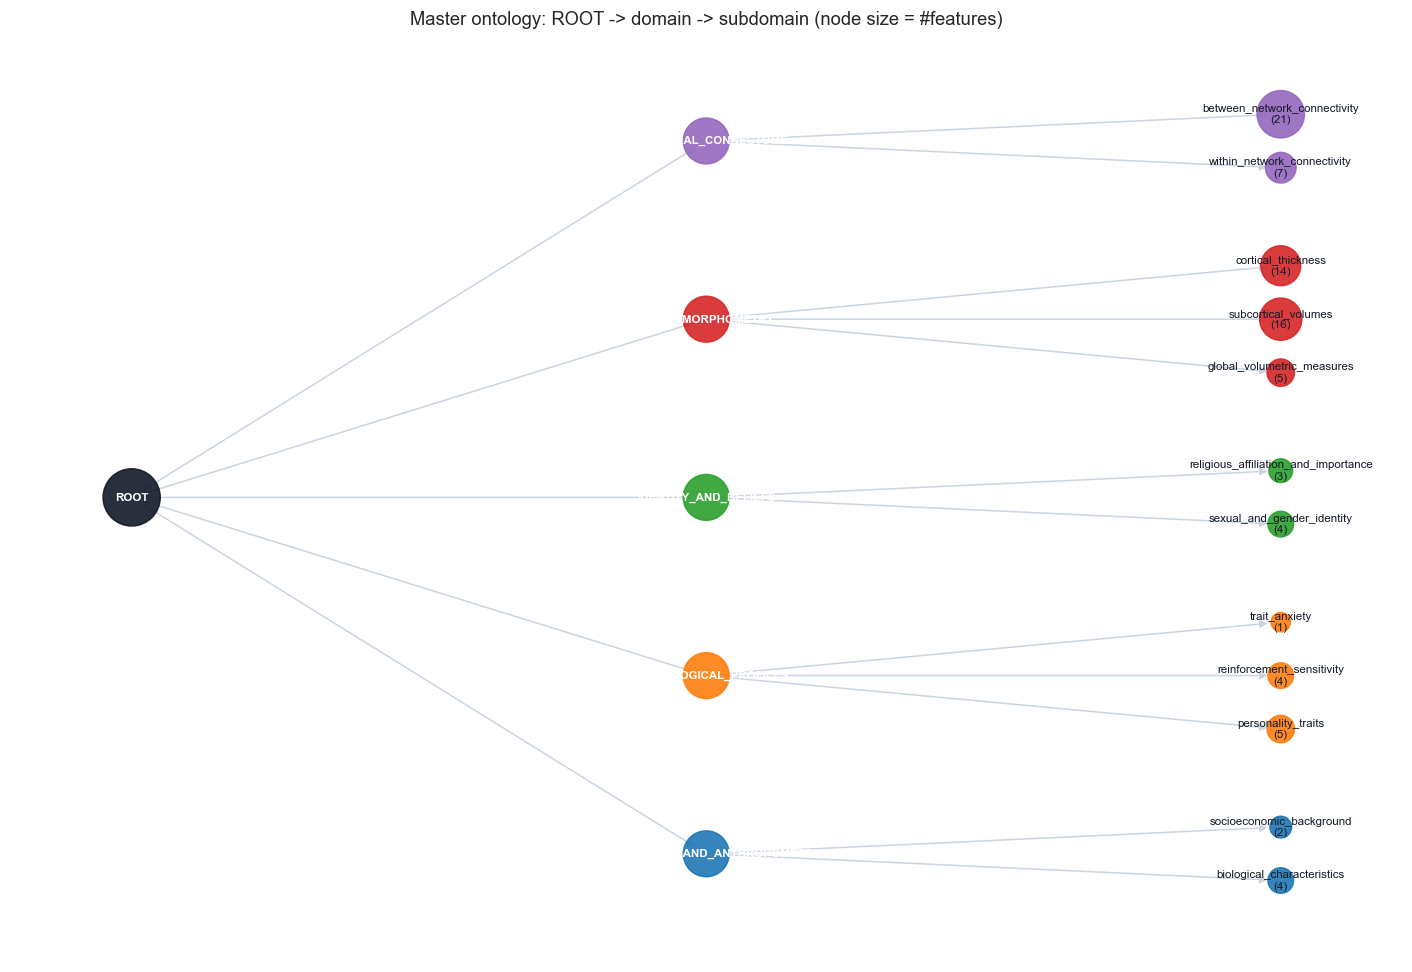

In [2]:
G = nx.DiGraph(); pos = {}; sizes=[]; colors=[]
palette = sns.color_palette("tab10", len(onto["domains"]))
G.add_node("ROOT"); pos["ROOT"]=(0,0); sizes.append(1400); colors.append("#111827")
ndom = len(onto["domains"])
for di,d in enumerate(onto["domains"]):
    dy = (di-(ndom-1)/2)*3
    G.add_node(d["id"]); G.add_edge("ROOT", d["id"]); pos[d["id"]]=(1,dy)
    sizes.append(900); colors.append(palette[di])
    ns=len(d["subdomains"])
    for si,s in enumerate(d["subdomains"]):
        sid=f"{d['id']}/{s['id']}"; sy=dy+(si-(ns-1)/2)*0.9
        G.add_node(sid, label=f"{s['id']}\n({len(s['features'])})"); G.add_edge(d["id"], sid)
        pos[sid]=(2, sy); sizes.append(120+40*len(s['features'])); colors.append(palette[di])
fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#cbd5e1")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=colors, alpha=0.9)
for n,(x,y) in pos.items():
    lbl = "ROOT" if n=="ROOT" else (dict(G.nodes(data=True)).get(n,{}).get("label") or n.split("/")[0])
    ax.text(x, y, lbl, fontsize=7.5, ha="center", va="center",
            color="white" if x<2 else "#111827", fontweight="bold" if x<2 else "normal")
ax.set_title("Master ontology: ROOT -> domain -> subdomain (node size = #features)"); ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Feature counts and data-driven clusters

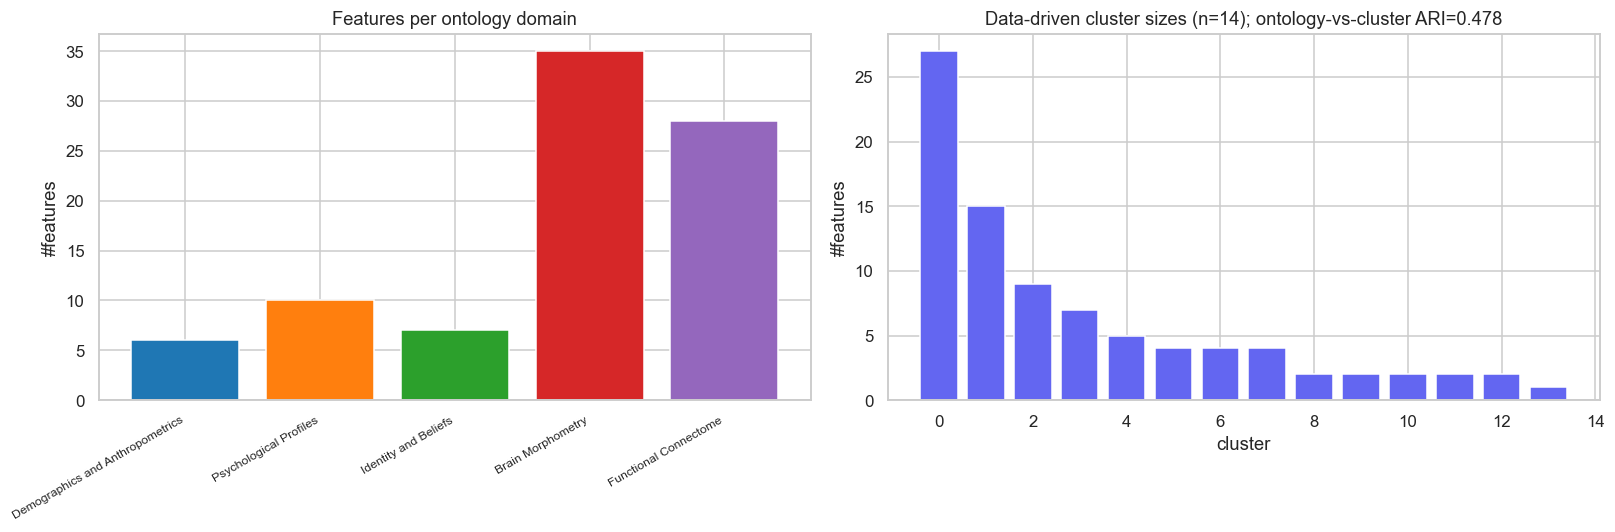

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
dom_counts = {d["label"]: sum(len(s["features"]) for s in d["subdomains"]) for d in onto["domains"]}
ax[0].bar(range(len(dom_counts)), list(dom_counts.values()),
          color=sns.color_palette("tab10", len(dom_counts)))
ax[0].set_xticks(range(len(dom_counts))); ax[0].set_xticklabels(list(dom_counts), rotation=30, ha="right", fontsize=8)
ax[0].set(title="Features per ontology domain", ylabel="#features")
csz = sorted((len(v) for v in explore["auto_clusters"].values()), reverse=True)
ax[1].bar(range(len(csz)), csz, color=IND)
ari = report.get("cluster_agreement",{}).get("adjusted_rand_index")
ax[1].set(title=f"Data-driven cluster sizes (n={len(csz)}); ontology-vs-cluster ARI={ari}",
          xlabel="cluster", ylabel="#features")
plt.tight_layout(); plt.show()

The adjusted Rand index compares the LLM's semantic subdomains against purely statistical clusters. Moderate agreement is expected and healthy: constructs like the Big Five are grouped by meaning even when they are not the tightest statistical cluster, while genuine redundancies below are grouped by both.

## 3. Redundancy detected by exploration

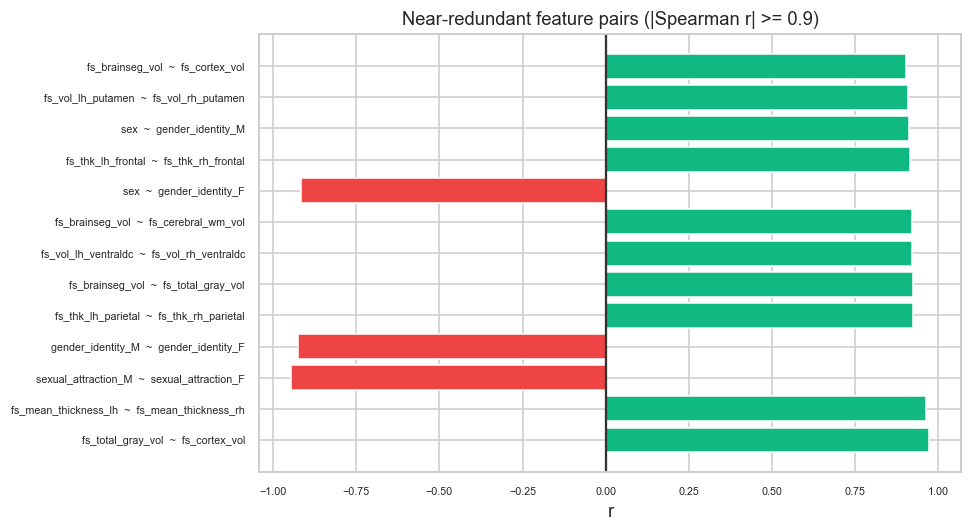

In [4]:
rp = pd.DataFrame(explore["redundant_pairs"])
if len(rp):
    rp["pair"] = rp["a"]+"  ~  "+rp["b"]
    rp = rp.reindex(rp["spearman_r"].abs().sort_values(ascending=False).index).head(13)
    fig, ax = plt.subplots(figsize=(9,5))
    ax.barh(rp["pair"], rp["spearman_r"], color=[RED if v<0 else GRN for v in rp["spearman_r"]])
    ax.axvline(0,color="#333"); ax.set(title="Near-redundant feature pairs (|Spearman r| >= 0.9)", xlabel="r")
    ax.tick_params(labelsize=7); plt.tight_layout(); plt.show()

## 4. Complexity tier ladder and per-tier performance

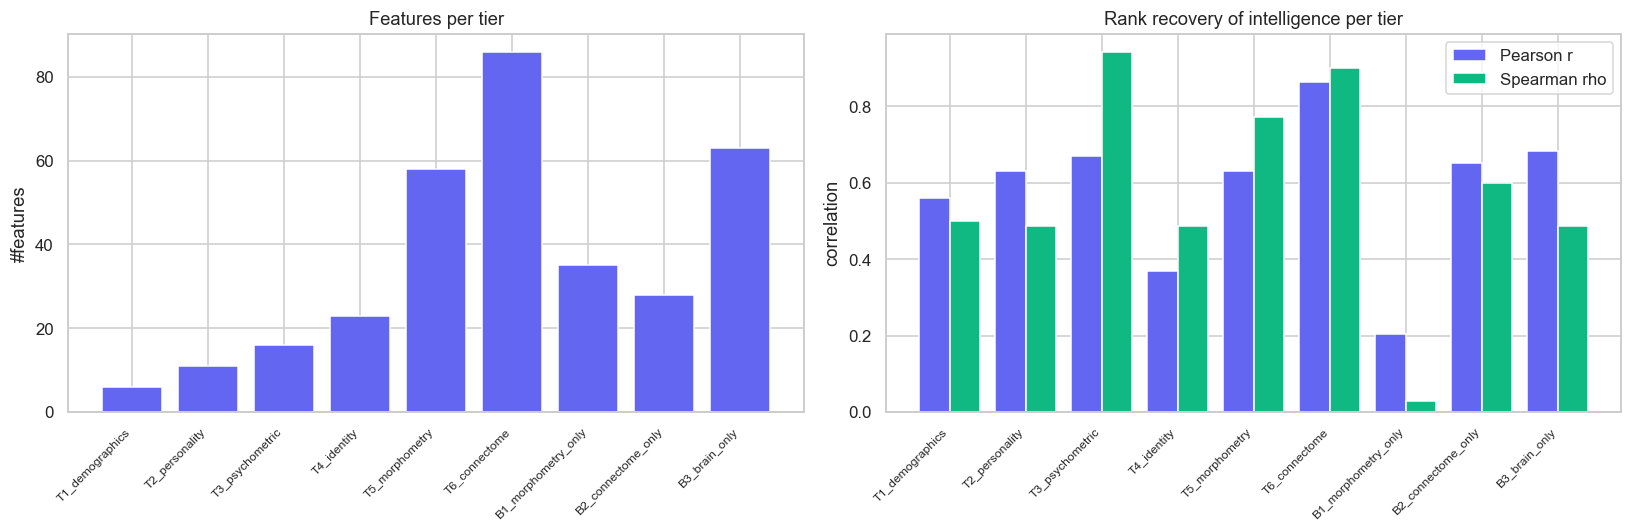

In [5]:
td = pd.DataFrame(tiers)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar(td["tier"], td["n_features"], color=IND)
ax[0].set_xticklabels(td["tier"], rotation=45, ha="right", fontsize=8)
ax[0].set(title="Features per tier", ylabel="#features")
x = np.arange(len(td)); w=0.4
ax[1].bar(x-w/2, td["pearson_r"], w, label="Pearson r", color=IND)
ax[1].bar(x+w/2, td["spearman_rho"], w, label="Spearman rho", color=GRN)
ax[1].set_xticks(x); ax[1].set_xticklabels(td["tier"], rotation=45, ha="right", fontsize=8)
ax[1].set(title="Rank recovery of intelligence per tier", ylabel="correlation"); ax[1].legend()
plt.tight_layout(); plt.show()

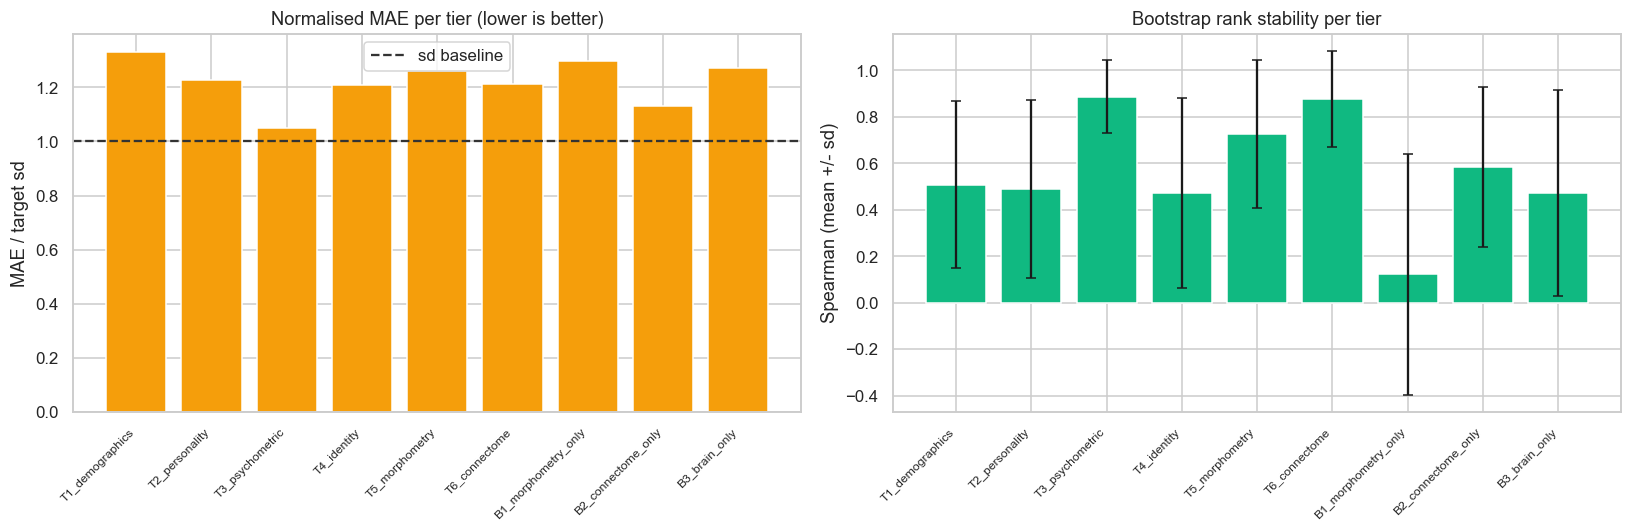

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar(x, td["normalised_mae"], color=ORG); ax[0].axhline(1.0, color="#333", ls="--", label="sd baseline")
ax[0].set_xticks(x); ax[0].set_xticklabels(td["tier"], rotation=45, ha="right", fontsize=8)
ax[0].set(title="Normalised MAE per tier (lower is better)", ylabel="MAE / target sd"); ax[0].legend()
ax[1].bar(x, td["rank_stability_mean"], yerr=td["rank_stability_sd"], color=GRN, capsize=3)
ax[1].set_xticks(x); ax[1].set_xticklabels(td["tier"], rotation=45, ha="right", fontsize=8)
ax[1].set(title="Bootstrap rank stability per tier", ylabel="Spearman (mean +/- sd)")
plt.tight_layout(); plt.show()

## 5. One participant as the engine sees it

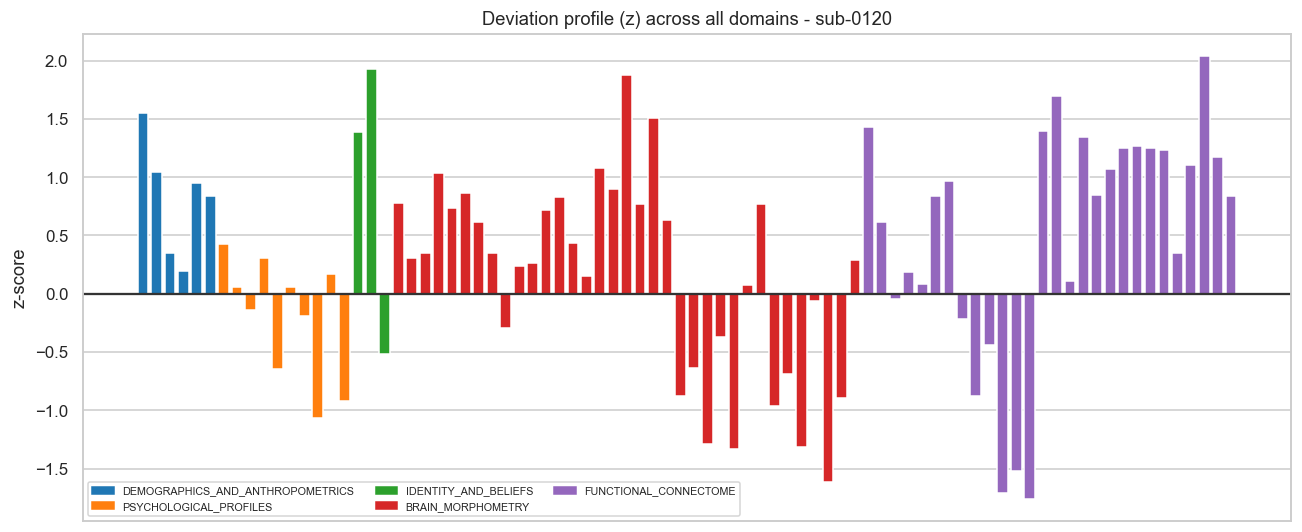

In [7]:
import glob
tdir = sorted(glob.glob(str(ROOT/"compass_inputs"/"T6_connectome"/"sub-*")))[0]
mm = json.load(open(Path(tdir)/"multimodal_data.json"))
rows=[]
for dom, subs in mm.items():
    for sub, payload in subs.items():
        for leaf in payload.get("_leaves", []):
            if leaf.get("z_score") is not None:
                rows.append({"domain":dom, "feature":leaf["feature"], "z":leaf["z_score"]})
zz = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(12,5))
palette = dict(zip(zz["domain"].unique(), sns.color_palette("tab10", zz["domain"].nunique())))
ax.bar(range(len(zz)), zz["z"], color=[palette[d] for d in zz["domain"]])
ax.axhline(0,color="#333"); ax.set(title=f"Deviation profile (z) across all domains - {Path(tdir).name}", ylabel="z-score")
ax.set_xticks([]);
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=d) for d,c in palette.items()], fontsize=7, ncol=3)
plt.tight_layout(); plt.show()

Every tier is a filtered projection of this one ontology, so the engine always receives a clean, non-redundant hierarchy; only the set of present leaf values changes.